In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("hr_employee_data.xlsx")

df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [7]:
print("rader:", df.shape[0])
print(" kolumner:", df.shape[1])

df.info()

rader: 14999
 kolumner: 11
<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB


In [8]:
df.isna().sum()

Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [9]:
print("Antal dubbletter:", df.duplicated().sum())
print("Dubbletter av Emp_Id:", df["Emp_Id"].duplicated().sum())

Antal dubbletter: 0
Dubbletter av Emp_Id: 0


In [10]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [11]:
df["left"].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

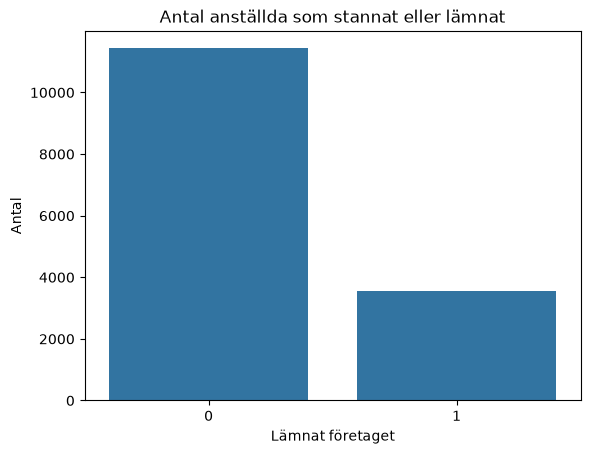

In [12]:
sns.countplot(data=df, x="left")
plt.title("Antal anställda som stannat eller lämnat")
plt.xlabel("Lämnat företaget")
plt.ylabel("Antal")
plt.show()

In [13]:
df["Department"].value_counts()

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

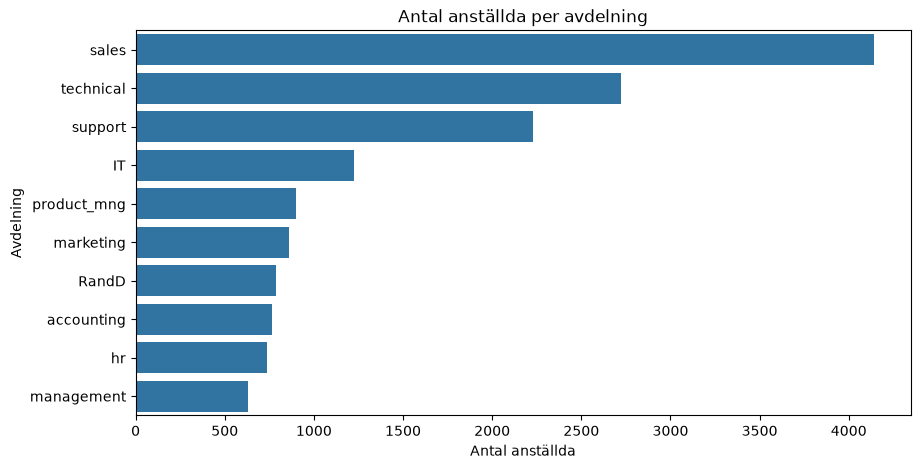

In [14]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="Department",
    order=df["Department"].value_counts().index
)

plt.title("Antal anställda per avdelning")
plt.xlabel("Antal anställda")
plt.ylabel("Avdelning")
plt.show()

In [15]:
department_left = (
    df.groupby("Department")["left"]
      .mean()
      .sort_values(ascending=False)
)

print(department_left)

Department
hr             0.290934
accounting     0.265971
technical      0.256250
support        0.248991
sales          0.244928
marketing      0.236597
IT             0.222494
product_mng    0.219512
RandD          0.153748
management     0.144444
Name: left, dtype: float64


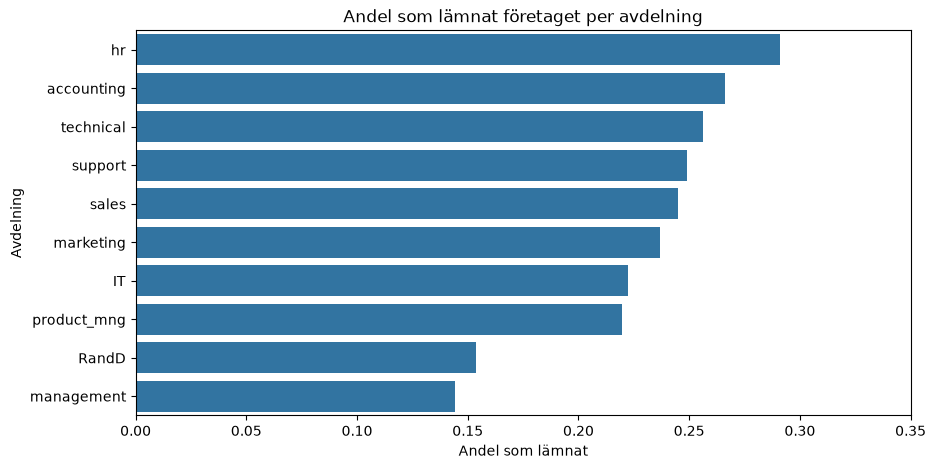

In [16]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=department_left.values,
    y=department_left.index
)

plt.title("Andel som lämnat företaget per avdelning")
plt.xlabel("Andel som lämnat")
plt.ylabel("Avdelning")
plt.xlim(0, 0.35)
plt.show()

In [17]:
salary_left = df.groupby("salary")["left"].mean()

print(salary_left)

salary
high      0.066289
low       0.296884
medium    0.204313
Name: left, dtype: float64


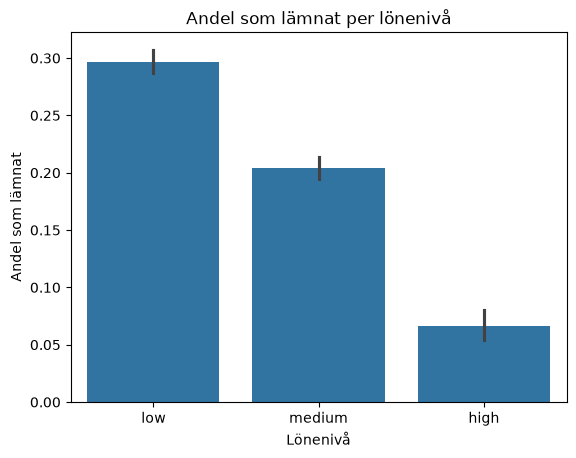

In [18]:
sns.barplot(
    data=df,
    x="salary",
    y="left"
)

plt.title("Andel som lämnat per lönenivå")
plt.ylabel("Andel som lämnat")
plt.xlabel("Lönenivå")
plt.show()

In [19]:
df.groupby("left")["satisfaction_level"].mean()

left
0    0.666810
1    0.440098
Name: satisfaction_level, dtype: float64

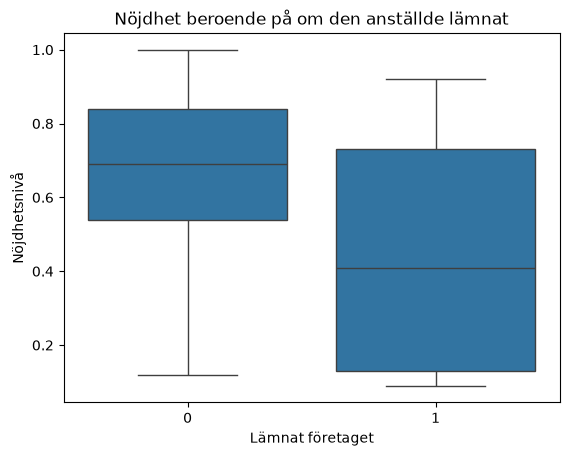

In [20]:
sns.boxplot(
    data=df,
    x="left",
    y="satisfaction_level"
)

plt.title("Nöjdhet beroende på om den anställde lämnat")
plt.xlabel("Lämnat företaget")
plt.ylabel("Nöjdhetsnivå")
plt.show()

In [21]:
df.groupby("left")["average_montly_hours"].mean()

left
0    199.060203
1    207.419210
Name: average_montly_hours, dtype: float64

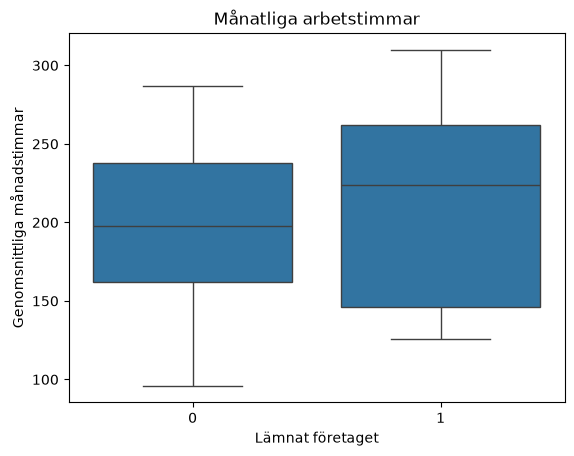

In [22]:
sns.boxplot(
    data=df,
    x="left",
    y="average_montly_hours"
)

plt.title("Månatliga arbetstimmar")
plt.xlabel("Lämnat företaget")
plt.ylabel("Genomsnittliga månadstimmar")
plt.show()

In [23]:
project_left = df.groupby("number_project")["left"].mean()

print(project_left)

number_project
2    0.656198
3    0.017756
4    0.093700
5    0.221659
6    0.557922
7    1.000000
Name: left, dtype: float64


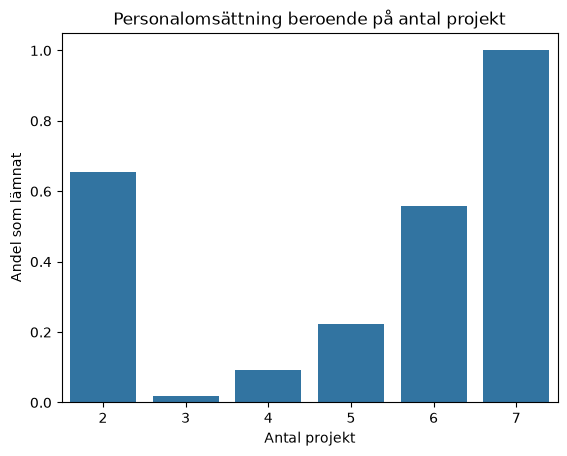

In [24]:
sns.barplot(
    x=project_left.index,
    y=project_left.values
)

plt.title("Personalomsättning beroende på antal projekt")
plt.xlabel("Antal projekt")
plt.ylabel("Andel som lämnat")
plt.show()

In [25]:
tenure_left = df.groupby("time_spend_company")["left"].mean()

print(tenure_left)

time_spend_company
2     0.016338
3     0.246159
4     0.348064
5     0.565513
6     0.291086
7     0.000000
8     0.000000
10    0.000000
Name: left, dtype: float64


In [26]:
df.groupby("time_spend_company")["left"].agg(["count", "sum", "mean"])

,count,sum,mean
time_spend_company,,,
2,3244,53,0.016338
3,6443,1586,0.246159
4,2557,890,0.348064
5,1473,833,0.565513
6,718,209,0.291086
7,188,0,0.000000
8,162,0,0.000000
10,214,0,0.000000


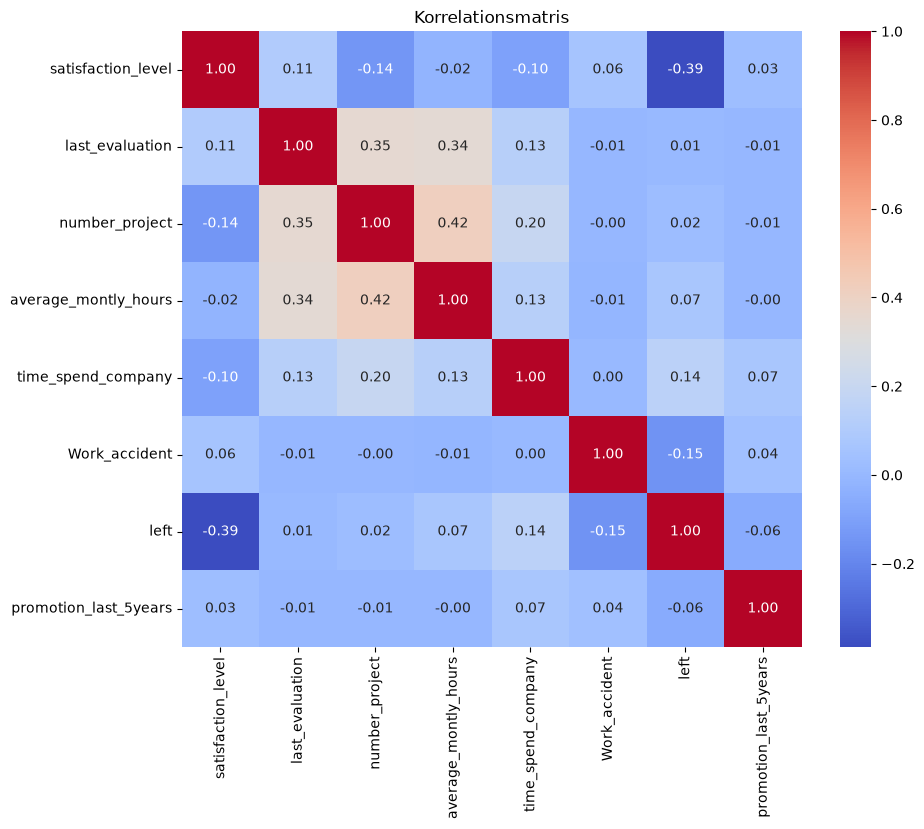

In [27]:
corr = df.select_dtypes("number").corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korrelationsmatris")
plt.show()

In [32]:
df.select_dtypes("number").corr()["left"].sort_values()

satisfaction_level      -0.388375
Work_accident           -0.154622
promotion_last_5years   -0.061788
last_evaluation          0.006567
number_project           0.023787
average_montly_hours     0.071287
time_spend_company       0.144822
left                     1.000000
Name: left, dtype: float64